# ==============================
# Graduate Admission Prediction
# ==============================

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# ==============================
# 1. Load Dataset
# ==============================

In [3]:
# Make sure dataset is in same folder
df = pd.read_csv("Admission_Predict.csv")

print("\nFirst 5 rows:\n", df.head())


First 5 rows:
    Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR   CGPA  \
0           1        337          118                  4  4.5   4.5  9.65   
1           2        324          107                  4  4.0   4.5  8.87   
2           3        316          104                  3  3.0   3.5  8.00   
3           4        322          110                  3  3.5   2.5  8.67   
4           5        314          103                  2  2.0   3.0  8.21   

   Research  Chance of Admit   
0         1              0.92  
1         1              0.76  
2         1              0.72  
3         1              0.80  
4         0              0.65  


# ==============================
# 2. Data Preprocessing
# ==============================


In [4]:
# Remove Serial No column if present
if "Serial No." in df.columns:
    df.drop("Serial No.", axis=1, inplace=True)

# Rename columns (remove spaces for easy coding)
df.columns = [col.strip().replace(" ", "_") for col in df.columns]

print("\nColumns:", df.columns)

# Check missing values
print("\nMissing values:\n", df.isnull().sum())


Columns: Index(['GRE_Score', 'TOEFL_Score', 'University_Rating', 'SOP', 'LOR', 'CGPA',
       'Research', 'Chance_of_Admit'],
      dtype='object')

Missing values:
 GRE_Score            0
TOEFL_Score          0
University_Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance_of_Admit      0
dtype: int64


# ==============================
# 3. Exploratory Data Analysis
# ==============================

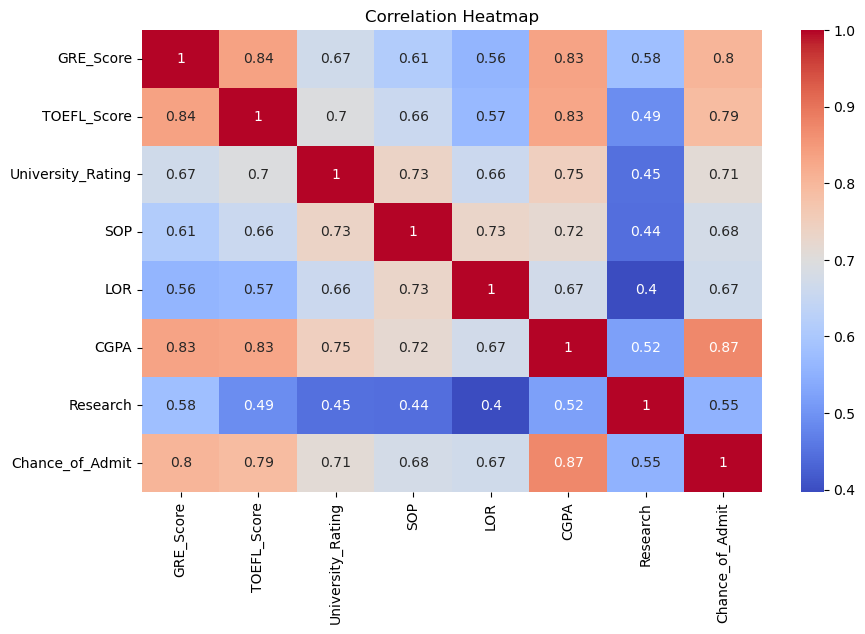

In [6]:
# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# ==============================
# 4. Feature Selection
# ==============================


In [8]:
X = df.drop("Chance_of_Admit", axis=1)
y = df["Chance_of_Admit"]

# ==============================
# 5. Train-Test Split
# ==============================

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# ==============================
# 6. Feature Scaling (for KNN)
# ==============================


In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==============================
# 7. Model Training
# ==============================

In [12]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5)
}

results = []


# ==============================
# 8. Training + Evaluation
# ==============================

In [13]:
for name, model in models.items():
    print(f"\nTraining {name}...")

    # Use scaled data for KNN only
    if name == "KNN":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    # Evaluation
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append([name, mae, mse, r2])

    print(f"{name} Results:")
    print("MAE:", mae)
    print("MSE:", mse)
    print("R2 Score:", r2)


Training Linear Regression...
Linear Regression Results:
MAE: 0.04795673362091196
MSE: 0.00461700337728501
R2 Score: 0.8212082591486991

Training Decision Tree...
Decision Tree Results:
MAE: 0.066125
MSE: 0.00947375
R2 Score: 0.6331325501680588

Training Random Forest...
Random Forest Results:
MAE: 0.04977500000000004
MSE: 0.004994038499999999
R2 Score: 0.8066077140670239

Training KNN...
KNN Results:
MAE: 0.05422499999999999
MSE: 0.006300049999999999
R2 Score: 0.7560329038328306



# ==============================
# 9. Results Comparison
# ==============================


Model Comparison:
                Model       MAE       MSE  R2 Score
0  Linear Regression  0.047957  0.004617  0.821208
1      Decision Tree  0.066125  0.009474  0.633133
2      Random Forest  0.049775  0.004994  0.806608
3                KNN  0.054225  0.006300  0.756033


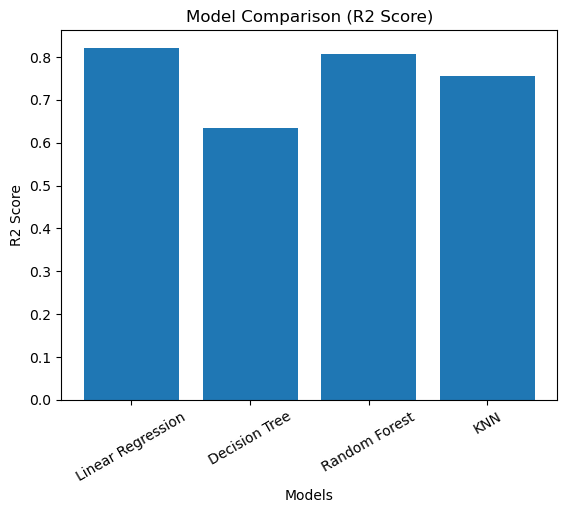

In [14]:
results_df = pd.DataFrame(results, columns=["Model", "MAE", "MSE", "R2 Score"])
print("\nModel Comparison:\n", results_df)

# Bar Plot for R2 Score
plt.figure()
plt.bar(results_df["Model"], results_df["R2 Score"])
plt.title("Model Comparison (R2 Score)")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.xticks(rotation=30)
plt.show()


# ==============================
# 10. Best Model
# ==============================

In [15]:
best_model = results_df.loc[results_df["R2 Score"].idxmax()]
print("\nBest Model:\n", best_model)


Best Model:
 Model       Linear Regression
MAE                  0.047957
MSE                  0.004617
R2 Score             0.821208
Name: 0, dtype: object


# ==============================
# 11. Sample Prediction
# ==============================

# Example input:
# GRE, TOEFL, Univ Rating, SOP, LOR, CGPA, Research

In [17]:
sample_df = pd.DataFrame(
    [[320, 110, 4, 4.5, 4, 9.0, 1]],
    columns=X.columns
)

# Use Random Forest (best usually)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


prediction = rf_model.predict(sample_df)
print("Chance of Admit:", prediction[0])

Chance of Admit: 0.8265000000000003
